# 04 - Generation: LangGraph orchestration + Citations

**Aligns with**: S4 Sec. 5 | **Estimated time**: 30 minutes | **Estimated cost**: ~$0.05

## Why LangGraph instead of a plain LCEL chain?

The chain in `00_quickstart` is **linear**: `retriever | prompt | llm | parser`.

But production RAG isn't linear:
- Short Q&A -> top-3 is enough, save tokens
- Long analytical -> top-8 + parent swap
- Empty retrieval -> **don't call the LLM**, refuse directly
- Low confidence -> rewrite query and retry (advanced, left as an exercise)

**This is a state machine with branches** - LangGraph's core use case.

```
[classify_query] -+- factual    -> [quick_retrieve k=3]
                  '- analytical -> [deep_retrieve k=8]
                                     |
                                     +- empty -> [refuse]    -> END
                                     '- found -> [generate]  -> END
```


In [4]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
from dotenv import load_dotenv; load_dotenv()

from src.pipelines.ingestion import IngestionPipeline
from src.pipelines.query import QueryPipeline
from src.chunkers import ParentChildChunker
from src.retrievers import VectorRetriever, BM25Retriever, HybridRetriever
from src.generators import RAGGenerator
from src.observability import CostTracker

## Step 1: A complete ingest + retrieve stack

In [5]:
cost = CostTracker()
pipeline = IngestionPipeline(cost_tracker=cost)
docs = [pipeline.ingest(str(ROOT / f"data/uploads/{n}.pdf")).document
        for n in ["wells_fargo", "tesla", "amd"]]

pc = ParentChildChunker(parent_size=800, child_size=150)
all_parents, all_children = [], []
for doc in docs:
    parents, children = pc.chunk_with_parents(doc)
    all_parents.extend(parents); all_children.extend(children)
print(f"{len(all_parents)} parents, {len(all_children)} children")

85 parents, 576 children


In [6]:
vec = VectorRetriever(
    persist_dir=str(ROOT / "tmp_chroma_04"), collection="lab_04",
    embeddings_cache_dir=ROOT / "cache/embeddings",
)
vec.reset(); vec.index(all_children)
bm = BM25Retriever(); bm.index(all_children)
hybrid = HybridRetriever(vec, bm, parent_store={p.chunk_id: p for p in all_parents})

generator = RAGGenerator(cost_tracker=cost)
qp = QueryPipeline(retriever=hybrid, generator=generator,
                    quick_k=3, deep_k=8, cost_tracker=cost)
print("QueryPipeline (LangGraph) ready")

QueryPipeline (LangGraph) ready


## Step 2: Inspect the graph - LangGraph has built-in mermaid rendering

In [7]:
print(qp.draw_mermaid())

%%{init: {'flowchart': {'curve': 'linear'}}}%%
graph TD;
	__start__([<p>__start__</p>]):::first
	classify(classify)
	quick_retrieve(quick_retrieve)
	deep_retrieve(deep_retrieve)
	generate(generate)
	refuse(refuse)
	__end__([<p>__end__</p>]):::last
	__start__ --> classify;
	generate --> __end__;
	refuse --> __end__;
	classify -.-> quick_retrieve;
	classify -.-> deep_retrieve;
	quick_retrieve -.-> generate;
	quick_retrieve -.-> refuse;
	deep_retrieve -.-> generate;
	deep_retrieve -.-> refuse;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



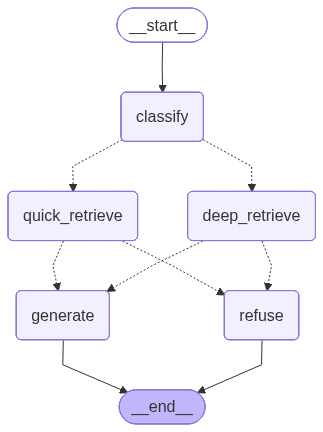

In [8]:
try:
    from IPython.display import Image, display
    display(Image(qp.graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(PNG render needs network. Markup is above. {type(e).__name__})")

## Step 3: Run a few queries, watch the branches

Note the `stages` field - it **records which path through the graph was taken**.
Critical for debugging.


In [9]:
queries = [
    "What was Wells Fargo's Q4 2025 net income?",
    "Compare segment performance across the three companies and discuss trends",
    "What was Apple's Q3 revenue?",
]

for q in queries:
    print(f"\n{'='*70}\nQ: {q}\n{'='*70}")
    result = qp.query(q)
    print(f"Stages: {' -> '.join(result['stages'])}")
    print(f"Type:   {result['query_type']}")
    print(f"Answer: {result['answer'][:300]}")
    print(f"Citations: {len(result['citations'])} | n_chunks: {len(result['chunks'])}")
    print(f"Refused: {result['refused']}")


Q: What was Wells Fargo's Q4 2025 net income?
Stages: classify→factual_lookup -> quick_retrieve→3 -> generate
Type:   factual_lookup
Answer: Wells Fargo's Q4 2025 net income was $5,361 million (reported as $5.4 billion in the press release) [^1][^2].
Citations: 2 | n_chunks: 3
Refused: False

Q: Compare segment performance across the three companies and discuss trends
Stages: classify→analytical -> deep_retrieve→8 -> generate
Type:   analytical
Answer: What I found in the sources:
- AMD: Record Q4 2025 revenue of "$10.3 billion", up 34% y/y [Source 2]. Data Center net revenue was "$5,380" million in Q4'25 vs "$3,859" million in Q4'24 (up 39% y/y); Data Center operating income was "$1,752" million vs "$1,157" million a year ago (up 51% y/y) [Source
Citations: 0 | n_chunks: 8
Refused: False

Q: What was Apple's Q3 revenue?
Stages: classify→factual_lookup -> quick_retrieve→3 -> generate
Type:   factual_lookup
Answer: What I found in the sources: The provided documents contain AMD’s finan

## Step 4: Total cost - accumulated across queries

In [ ]:
print("Cost breakdown:")
for stage, c in cost.by_stage.items():
    n = cost.n_calls.get(stage, 0)
    print(f"  {stage:25s} ${c:.5f}  ({n} calls)")
print(f"\n   TOTAL:    ${cost.total:.5f}")

## Step 5: Citation traceback

In [ ]:
result = qp.query("What was Wells Fargo's Q4 2025 net income?")
chunk_lookup = {c.chunk_id: c for c in result["chunks"]}

print(f"Answer: {result['answer']}\n")
print(f"Cited sources ({len(result['citations'])}):")
for i, cid in enumerate(result["citations"], 1):
    if cid in chunk_lookup:
        ch = chunk_lookup[cid]
        hp = ' > '.join(ch.heading_path) if ch.heading_path else ''
        print(f"\n  [^{i}] page {ch.page_number} {hp}")
        print(f"      {ch.text[:200]}{'...' if len(ch.text) > 200 else ''}")

## Recap

| Concept | Implementation |
|---|---|
| State machine | `QueryState` TypedDict passed between nodes |
| Conditional edges | `add_conditional_edges` for routing |
| Refusal short-circuit | empty retrieval -> `refuse` node, no LLM call |
| Observable nodes | every node `@traceable` |
| Cost transparency | shared `CostTracker` |

## Exercise 4.A

Add a **`rewrite_query` node**: when retrieval returns < 2 chunks, ask the LLM
to rewrite the query and retry. Add an `n_rewrites` counter to prevent infinite
loops.
